# **1. Perkenalan Dataset**


Tahap pertama, Anda harus mencari dan menggunakan dataset dengan ketentuan sebagai berikut:

1. **Sumber Dataset**:  
    Dataset yang digunakan pada penelitian ini diperoleh dari UCI Machine Learning Repository, yaitu Wine Quality Dataset. Dataset tersebut merupakan dataset publik yang banyak digunakan dalam penelitian machine learning dan tersedia secara terbuka untuk keperluan analisis serta pengembangan model prediksi.


# **2. Import Library**

Pada tahap ini, Anda perlu mengimpor beberapa pustaka (library) Python yang dibutuhkan untuk analisis data dan pembangunan model machine learning atau deep learning.

In [1]:
!pip install numpy pandas matplotlib scikit-learn joblib mlflow
!nohup mlflow server --host 127.0.0.1 --port 5000 &

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.4/49.4 kB 2.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.2/50.2 kB 2.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.5/43.5 kB 1.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.8/10.8 MB 32.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 32.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 20.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 147.8/147.8 kB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 212.0/212.0 kB 8.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.3/86.3 kB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 132.2/132.2 kB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 907.0/907.0 kB 28.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.

In [2]:
!pip install mlflow
import pandas as pd
import numpy as np
import random
import mlflow
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris
from sklearn.linear_model import SGDClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import (
    MinMaxScaler,
    StandardScaler,
    OneHotEncoder
)
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.utils import shuffle

from joblib import dump, load

# **3. Memuat Dataset**

Pada tahap ini, Anda perlu memuat dataset ke dalam notebook. Jika dataset dalam format CSV, Anda bisa menggunakan pustaka pandas untuk membacanya. Pastikan untuk mengecek beberapa baris awal dataset untuk memahami strukturnya dan memastikan data telah dimuat dengan benar.

Jika dataset berada di Google Drive, pastikan Anda menghubungkan Google Drive ke Colab terlebih dahulu. Setelah dataset berhasil dimuat, langkah berikutnya adalah memeriksa kesesuaian data dan siap untuk dianalisis lebih lanjut.

Jika dataset berupa unstructured data, silakan sesuaikan dengan format seperti kelas Machine Learning Pengembangan atau Machine Learning Terapan

In [5]:
!nohup mlflow ui --port 5000 &

!unzip -o /content/wine+quality.zip -d /content/

# Memuat dataset
data = pd.read_csv('/content/winequality-red.csv', sep=';')

# Menampilkan data awal
print(data.head())

# Set MLflow Tracking URI
mlflow.set_tracking_uri("http://127.0.0.1:5000/")

# Create a new MLflow Experiment
mlflow.set_experiment("Online Training Wine")

# Model Online Learning: SGDClassifier
model = SGDClassifier(
    loss='log_loss',
    learning_rate='adaptive',
    eta0=0.01,
    max_iter=10000
)

# Kelas target
classes = data['quality'].unique()

with mlflow.start_run():

    mlflow.autolog()

    # Feature dan target
    X_batch = data.drop(columns=['quality'])
    y_batch = data['quality']

    # Training
    model.partial_fit(
        X_batch,
        y_batch,
        classes=classes
    )

    # Accuracy
    accuracy = model.score(
        X_batch,
        y_batch
    )

    mlflow.log_metric(
        "accuracy",
        accuracy
    )

    print(f"Accuracy: {accuracy:.4f}")

    # Simpan model
    dump(
        model,
        "online_model.joblib"
    )

    # Log artifact
    mlflow.log_artifact(
        "online_model.joblib",
        artifact_path="model_artifacts"
    )

    # Log model
    mlflow.sklearn.log_model(
        sk_model=model,
        artifact_path="online_model",
        input_example=X_batch.iloc[:5]
    )

nohup: appending output to 'nohup.out'
Archive:  /content/wine+quality.zip
  inflating: /content/winequality-red.csv  
  inflating: /content/winequality-white.csv  
  inflating: /content/winequality.names  
   fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
0            7.4              0.70         0.00             1.9      0.076   
1            7.8              0.88         0.00             2.6      0.098   
2            7.8              0.76         0.04             2.3      0.092   
3           11.2              0.28         0.56             1.9      0.075   
4            7.4              0.70         0.00             1.9      0.076   

   free sulfur dioxide  total sulfur dioxide  density    pH  sulphates  \
0                 11.0                  34.0   0.9978  3.51       0.56   
1                 25.0                  67.0   0.9968  3.20       0.68   
2                 15.0                  54.0   0.9970  3.26       0.65   
3                 17.0      

2026/06/01 15:42:50 INFO mlflow.tracking.fluent: Experiment with name 'Online Training Wine' does not exist. Creating a new experiment.
2026/06/01 15:43:03 INFO mlflow.tracking.fluent: Autologging successfully enabled for sklearn.
2026/06/01 15:43:29 INFO mlflow.tracking.fluent: Autologging successfully enabled for statsmodels.
2026/06/01 15:43:29 WARNING mlflow.spark: With Pyspark >= 3.2, PYSPARK_PIN_THREAD environment variable must be set to false for Spark datasource autologging to work.
2026/06/01 15:43:29 INFO mlflow.tracking.fluent: Autologging successfully enabled for pyspark.


Accuracy: 0.2570


2026/06/01 15:43:30 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/06/01 15:43:31 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
/usr/local/lib/python3.12/dist-packages/mlflow/types/utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can 

🏃 View run traveling-lynx-186 at: http://127.0.0.1:5000/#/experiments/1/runs/8a50e7a0aace465e97dee1507f10bce4
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1


In [6]:
# Memuat dataset
iris = load_iris()
data = pd.DataFrame(iris.data, columns=iris.feature_names)
data['target'] = iris.target

# Shuffle dataset untuk simulasi data streaming
data = shuffle(data, random_state=42)

# Split data menjadi batch kecil untuk simulasi data streaming
batch_size = 60  # Ukuran batch
batches = [data.iloc[i:i + batch_size] for i in range(0, len(data), batch_size)]

In [7]:
# Set MLflow Tracking URI
mlflow.set_tracking_uri("http://127.0.0.1:5000/")

# Create a new MLflow Experiment
mlflow.set_experiment("Online Training Wine")

# Nama eksperimen yang ingin dicari
experiment_name = "Online Training Wine"

# Mendapatkan ID eksperimen
experiment = mlflow.get_experiment_by_name(experiment_name)
experiment_id = experiment.experiment_id

# Mendapatkan semua runs dalam eksperimen dan memilih run terbaru
runs = mlflow.search_runs(experiment_ids=[experiment_id], order_by=["start_time DESC"])
latest_run_id = runs.iloc[0]["run_id"]  # Run ID terbaru

# Mendapatkan path model dari MLflow artifact
artifact_uri = f"runs:/{latest_run_id}/model_artifacts/online_model.joblib"
local_path = mlflow.artifacts.download_artifacts(artifact_uri)

# Memuat model untuk partial_fit
model = load(local_path)

In [8]:
with mlflow.start_run():
    mlflow.autolog()  # Melakukan logging otomatis

    # Fix: Reload the Wine Quality dataset for online training batches
    wine_data_for_batch = pd.read_csv('/content/winequality-red.csv', sep=';')

    # Preprocessing data untuk batch dari Wine Quality dataset
    X_batch = wine_data_for_batch.drop(columns=['quality'])
    y_batch = wine_data_for_batch['quality']

    # Update model dengan batch berikutnya
    model.partial_fit(X_batch, y_batch)

    # Log metrik setelah setiap batch
    batch_accuracy = model.score(X_batch, y_batch)
    mlflow.log_metric("batch_accuracy", batch_accuracy)
    # Simpan model ke file lokal
    dump(model, "online_model.joblib")

    # Log file model sebagai artefak ke MLflow
    mlflow.log_artifact("online_model.joblib", artifact_path="model_artifacts")
    # Log model setelah selesai online training
    mlflow.sklearn.log_model(
        sk_model=model,
        artifact_path="online_model",
        input_example=X_batch.iloc[:5]
    )

2026/06/01 15:45:30 INFO mlflow.tracking.fluent: Autologging successfully enabled for sklearn.
2026/06/01 15:45:30 INFO mlflow.tracking.fluent: Autologging successfully enabled for statsmodels.
2026/06/01 15:45:30 WARNING mlflow.spark: With Pyspark >= 3.2, PYSPARK_PIN_THREAD environment variable must be set to false for Spark datasource autologging to work.
2026/06/01 15:45:30 INFO mlflow.tracking.fluent: Autologging successfully enabled for pyspark.
2026/06/01 15:45:31 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/06/01 15:45:33 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
/usr/local/lib/python3.12/dist-packag

🏃 View run treasured-hog-910 at: http://127.0.0.1:5000/#/experiments/1/runs/2a153528894a4df5bc736f5762bd0395
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1


# **4. Exploratory Data Analysis (EDA)**
Pada tahap ini, Anda akan melakukan **Exploratory Data Analysis (EDA)** untuk memahami karakteristik dataset.

Tujuan dari EDA adalah untuk memperoleh wawasan awal yang mendalam mengenai data dan menentukan langkah selanjutnya dalam analisis atau pemodelan.

5 Data Pertama:
   fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
0            7.4              0.70         0.00             1.9      0.076   
1            7.8              0.88         0.00             2.6      0.098   
2            7.8              0.76         0.04             2.3      0.092   
3           11.2              0.28         0.56             1.9      0.075   
4            7.4              0.70         0.00             1.9      0.076   

   free sulfur dioxide  total sulfur dioxide  density    pH  sulphates  \
0                 11.0                  34.0   0.9978  3.51       0.56   
1                 25.0                  67.0   0.9968  3.20       0.68   
2                 15.0                  54.0   0.9970  3.26       0.65   
3                 17.0                  60.0   0.9980  3.16       0.58   
4                 11.0                  34.0   0.9978  3.51       0.56   

   alcohol  quality  
0      9.4        5  
1      9.8        5  
2   

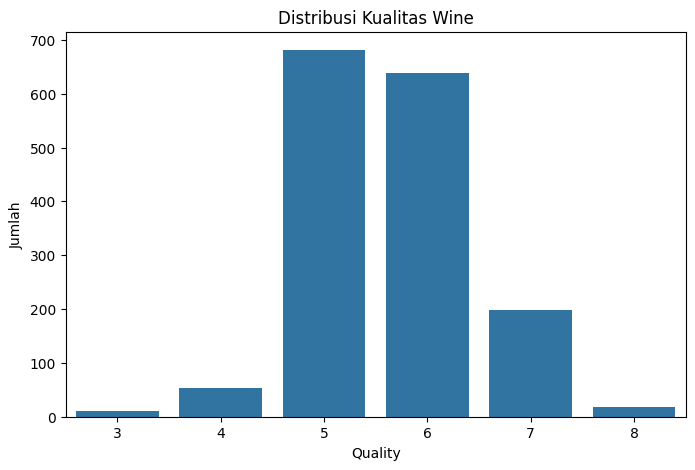

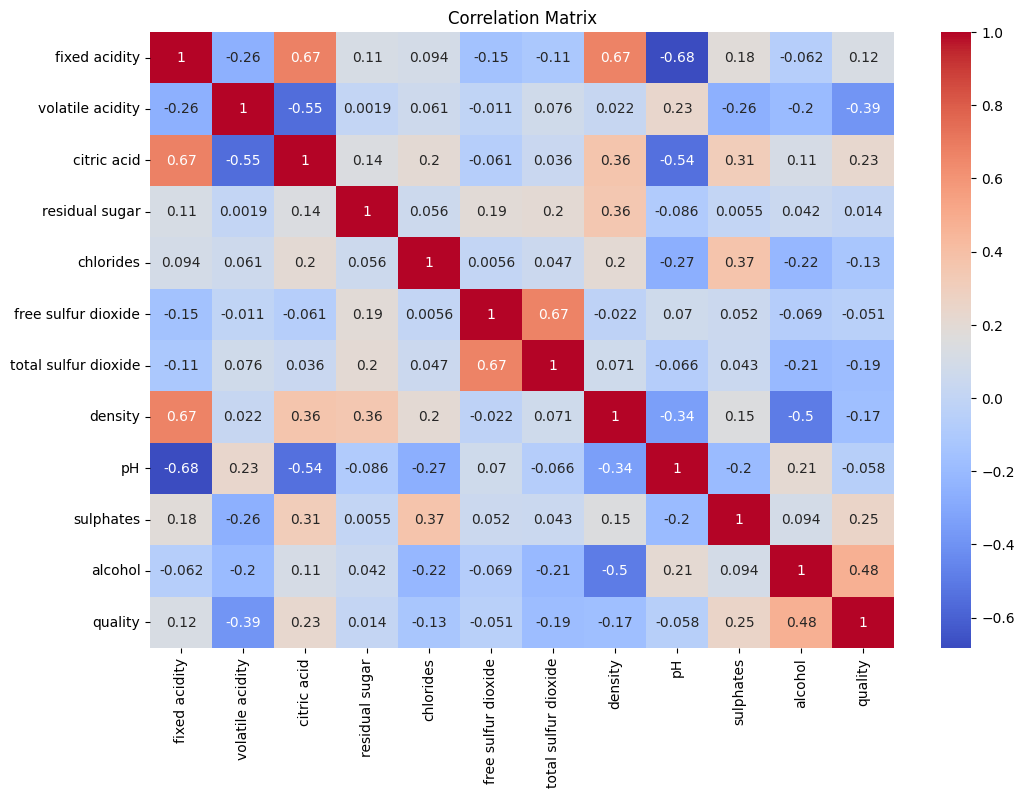

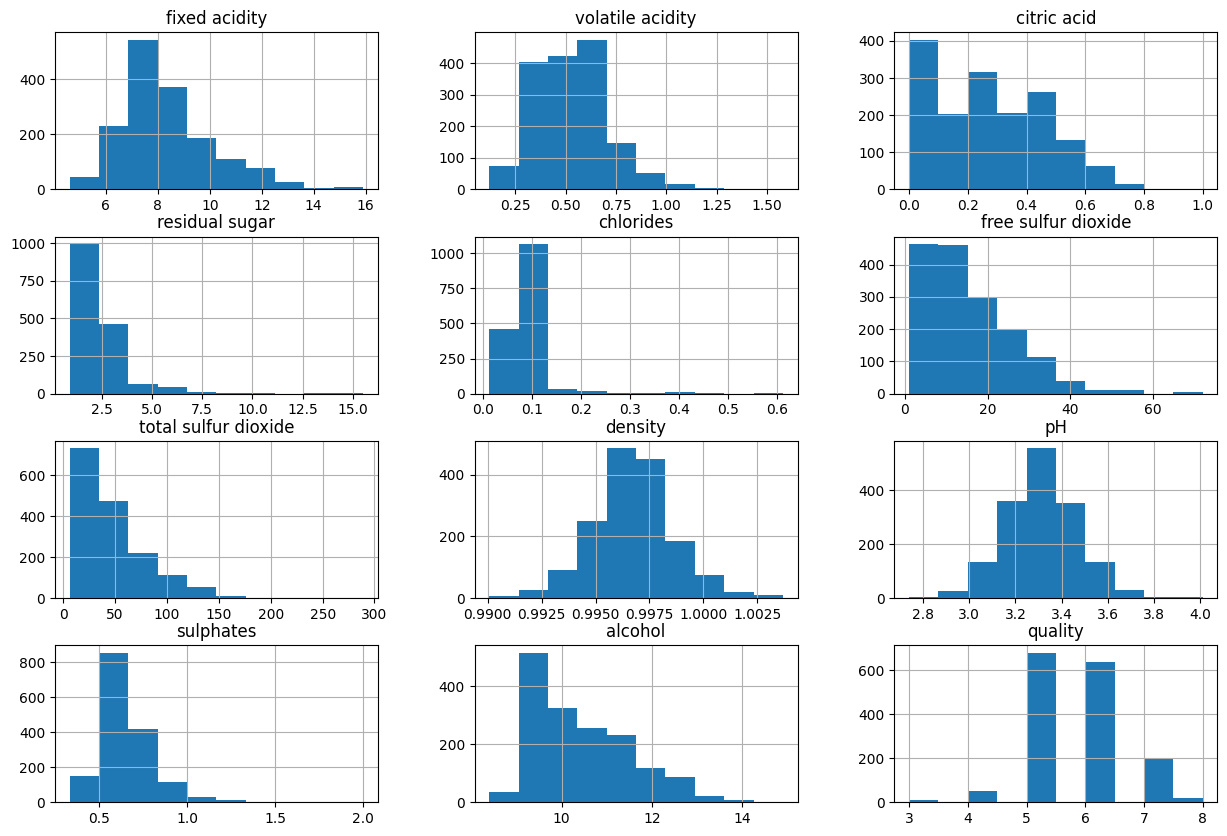

In [9]:
# Memuat dataset Wine Quality untuk EDA
data = pd.read_csv('/content/winequality-red.csv', sep=';')

# Menampilkan 5 data pertama
print("5 Data Pertama:")
print(data.head())

# Ukuran dataset
print("\nUkuran Dataset:")
print(data.shape)

# Informasi dataset
print("\nInformasi Dataset:")
print(data.info())

# Statistik deskriptif
print("\nStatistik Deskriptif:")
print(data.describe())

# Missing value
print("\nMissing Value:")
print(data.isnull().sum())

# Data duplikat
print("\nJumlah Data Duplikat:")
print(data.duplicated().sum())

# Distribusi target
print("\nDistribusi Quality:")
print(data['quality'].value_counts())

# Visualisasi distribusi kualitas wine
plt.figure(figsize=(8,5))
sns.countplot(x='quality', data=data)
plt.title('Distribusi Kualitas Wine')
plt.xlabel('Quality')
plt.ylabel('Jumlah')
plt.show()

# Korelasi antar variabel
plt.figure(figsize=(12,8))
sns.heatmap(data.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

# Distribusi setiap fitur
data.hist(figsize=(15,10))
plt.show()

# **5. Data Preprocessing**

Pada tahap ini, data preprocessing adalah langkah penting untuk memastikan kualitas data sebelum digunakan dalam model machine learning.

Jika Anda menggunakan data teks, data mentah sering kali mengandung nilai kosong, duplikasi, atau rentang nilai yang tidak konsisten, yang dapat memengaruhi kinerja model. Oleh karena itu, proses ini bertujuan untuk membersihkan dan mempersiapkan data agar analisis berjalan optimal.

Berikut adalah tahapan-tahapan yang bisa dilakukan, tetapi **tidak terbatas** pada:
1. Menghapus atau Menangani Data Kosong (Missing Values)
2. Menghapus Data Duplikat
3. Normalisasi atau Standarisasi Fitur
4. Deteksi dan Penanganan Outlier
5. Encoding Data Kategorikal
6. Binning (Pengelompokan Data)

Cukup sesuaikan dengan karakteristik data yang kamu gunakan yah. Khususnya ketika kami menggunakan data tidak terstruktur.

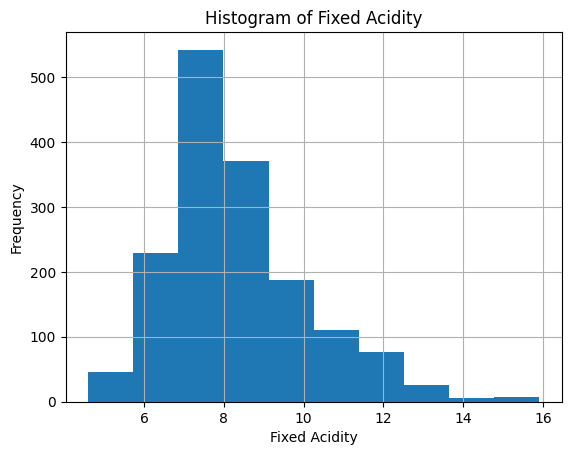

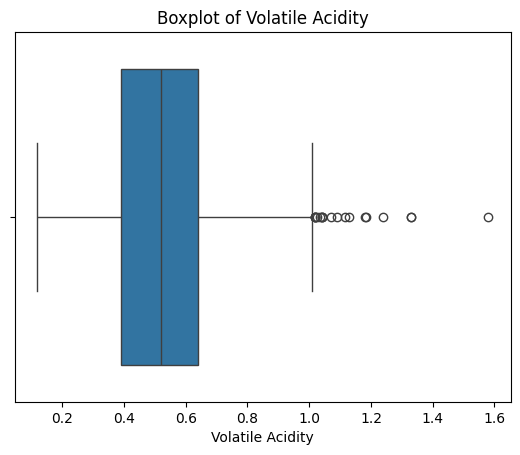

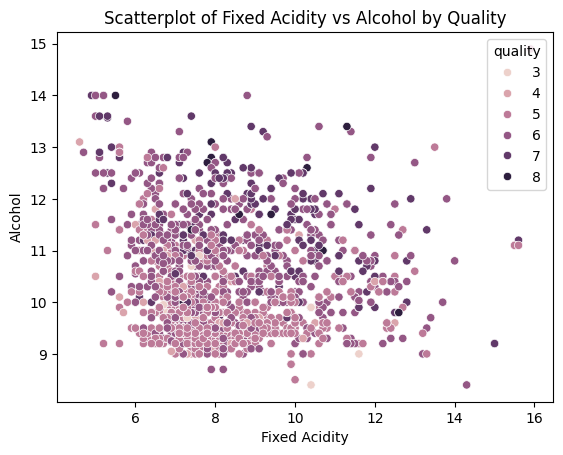

In [10]:
# Histogram of 'fixed acidity'
data['fixed acidity'].hist()
plt.title('Histogram of Fixed Acidity')
plt.xlabel('Fixed Acidity')
plt.ylabel('Frequency')
plt.show()

# Boxplot of 'volatile acidity'
sns.boxplot(x=data['volatile acidity'])
plt.title('Boxplot of Volatile Acidity')
plt.xlabel('Volatile Acidity')
plt.show()

# Scatterplot of 'fixed acidity' vs 'alcohol' with 'quality' as hue
sns.scatterplot(x=data['fixed acidity'], y=data['alcohol'], hue=data['quality'])
plt.title('Scatterplot of Fixed Acidity vs Alcohol by Quality')
plt.xlabel('Fixed Acidity')
plt.ylabel('Alcohol')
plt.show()

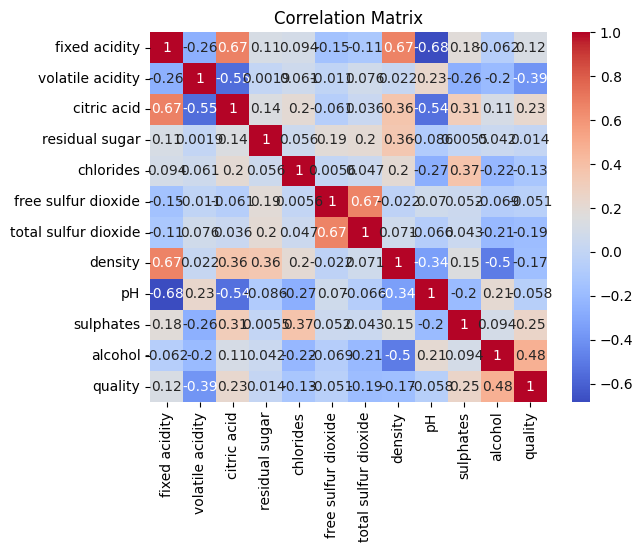

In [11]:
# Matriks Korelasi
corr_matrix = data.corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

In [12]:
imputer = SimpleImputer(strategy='mean')
feature_columns = data.columns.drop('quality')
data[feature_columns] = imputer.fit_transform(data[feature_columns])

In [13]:
# Mengecek missing value
print(data.isnull().sum())

# Menghapus data duplikat
data = data.drop_duplicates()

# Memisahkan fitur dan target
X = data.drop('quality', axis=1)
y = data['quality']

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Standardisasi fitur
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64


In [14]:
# Menghapus Outlier berdasarkan IQR
# Get feature names from the current 'data' DataFrame, excluding the target column 'quality'
wine_features = data.columns.drop('quality')

for feature in wine_features:
    Q1 = data[feature].quantile(0.25)
    Q3 = data[feature].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    data = data[(data[feature] >= lower_bound) & (data[feature] <= upper_bound)]

In [15]:
# Normalisasi
scaler = MinMaxScaler()
# Get feature names from the current 'data' DataFrame, excluding the target column 'quality'
wine_features_to_normalize = data.columns.drop('quality')
data[wine_features_to_normalize] = scaler.fit_transform(data[wine_features_to_normalize])

In [16]:
# One-Hot Encoding
encoder = OneHotEncoder()
encoded_target = encoder.fit_transform(data[['quality']])

In [17]:
X = data.drop('quality', axis=1)
y = data['quality']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [18]:
def preprocess_data(data, target_column, save_path, file_path):
    # Menentukan fitur numerik dan kategoris
    numeric_features = data.select_dtypes(include=['float64', 'int64']).columns.tolist()
    categorical_features = data.select_dtypes(include=['object']).columns.tolist()
    column_names = data.columns
    # Mendapatkan nama kolom tanpa kolom target
    column_names = data.columns.drop(target_column)

    # Membuat DataFrame kosong dengan nama kolom
    df_header = pd.DataFrame(columns=column_names)

    # Menyimpan nama kolom sebagai header tanpa data
    df_header.to_csv(file_path, index=False)
    print(f"Nama kolom berhasil disimpan ke: {file_path}")

    # Pastikan target_column tidak ada di numeric_features atau categorical_features
    if target_column in numeric_features:
        numeric_features.remove(target_column)
    if target_column in categorical_features:
        categorical_features.remove(target_column)

    # Pipeline untuk fitur numerik
    numeric_transformer = Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='mean')),
        ('scaler', StandardScaler())
    ])

    # Pipeline untuk fitur kategoris
    categorical_transformer = Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
        ('encoder', OneHotEncoder(handle_unknown='ignore'))
    ])

    # Column Transformer
    preprocessor = ColumnTransformer(
        transformers=[
            ('num', numeric_transformer, numeric_features),
            ('cat', categorical_transformer, categorical_features)
        ]
    )

    # Memisahkan target
    X = data.drop(columns=[target_column])
    y = data[target_column]

    # Membagi data
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

    # Fitting dan transformasi data pada training set
    X_train = preprocessor.fit_transform(X_train)
    # Transformasi data pada testing set
    X_test = preprocessor.transform(X_test)
    # Simpan pipeline
    dump(preprocessor, save_path)

    return X_train, X_test, y_train, y_test

In [19]:
# Memuat dataset
iris = load_iris()
data = pd.DataFrame(iris.data, columns=iris.feature_names)
data['target'] = iris.target
data.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [20]:
X_train, X_test, y_train, y_test = preprocess_data(data, 'target', 'preprocessor_pipeline.joblib', 'data.csv')

2026/06/01 15:46:11 INFO mlflow.utils.autologging_utils: Created MLflow autologging run with ID '4940e49a02544c1ebbe248673e050c9e', which will track hyperparameters, performance metrics, model artifacts, and lineage information for the current sklearn workflow


Nama kolom berhasil disimpan ke: data.csv


2026/06/01 15:46:11 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/06/01 15:46:11 WARNING mlflow.sklearn: Model was missing function: predict. Not logging python_function flavor!
2026/06/01 15:46:21 WARNING mlflow.sklearn: Training metrics will not be recorded because training labels were not specified. To automatically record training metrics, provide training labels as inputs to the model training function.


🏃 View run bemused-snake-865 at: http://127.0.0.1:5000/#/experiments/1/runs/4940e49a02544c1ebbe248673e050c9e
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1


In [21]:
def inference(new_data, load_path):
    # Memuat pipeline preprocessing
    preprocessor = load(load_path)
    print(f"Pipeline preprocessing dimuat dari: {load_path}")

    # Transformasi data baru
    transformed_data = preprocessor.transform(new_data)
    return transformed_data


In [22]:
# Jalankan preprocessing
pipeline_path = 'preprocessor_pipeline.joblib'
col = pd.read_csv('data.csv')
# Daftar data
new_data = [5.1, 3.5, 1.4, 0.2]

# Mengubah menjadi numpy.ndarray
new_data = np.array(new_data)

new_data = pd.DataFrame([new_data], columns=col.columns)
# Lakukan inference
transformed_data = inference(new_data, pipeline_path)
print(new_data)

Pipeline preprocessing dimuat dari: preprocessor_pipeline.joblib
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
0                5.1               3.5                1.4               0.2


In [23]:
import pandas as pd

def preprocess_data(input_file, output_file):

    data = pd.read_csv(input_file, sep=';')

    data = data.drop_duplicates()

    data.to_csv(output_file, index=False)

if __name__ == "__main__":
    preprocess_data(
        "/content/winequality-red.csv",
        "wine_preprocessing.csv"
    )